In [1188]:
import os
from pathlib import Path

# Step 1: Check if folder exists
folder = Path("./../bot - 4/").resolve()
print(f"Folder exists: {folder.exists()}")
print(f"Folder path: {folder}")

# Step 2: List files in folder
if folder.exists():
    files = list(folder.glob("**/*"))
    print(f"Total items: {len(files)}")
    for f in files[:5]:  # First 5 files
        print(f"  - {f}")

Folder exists: True
Folder path: /workspace/NIKHIL/bot - 4
Total items: 83
  - /workspace/NIKHIL/bot - 4/individual_chunking.ipynb
  - /workspace/NIKHIL/bot - 4/individual_chunking-Copy1.ipynb
  - /workspace/NIKHIL/bot - 4/.ipynb_checkpoints
  - /workspace/NIKHIL/bot - 4/CSJM_DOCUMENTS
  - /workspace/NIKHIL/bot - 4/compressed_folder.zip


In [1186]:
import zipfile
import os
from pathlib import Path

def zip_folder_advanced(folder_path, output_zip_path, exclude=None):
    """
    Compress a folder with error handling and exclusions
    
    Args:
        folder_path: Path to folder to compress
        output_zip_path: Output zip file path (include .zip)
        exclude: List of file patterns to exclude (e.g., ['.pyc', '__pycache__'])
    """
    if exclude is None:
        exclude = []
    
    folder_path = Path(folder_path)
    
    if not folder_path.exists():
        print(f"Error: Folder '{folder_path}' does not exist")
        return False
    
    try:
        with zipfile.ZipFile(output_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            file_count = 0
            for root, dirs, files in os.walk(folder_path):
                for file in files:
                    file_path = Path(root) / file
                    
                    # Skip excluded files
                    if any(exc in str(file_path) for exc in exclude):
                        continue
                    
                    arcname = file_path.relative_to(folder_path)
                    zipf.write(file_path, arcname)
                    file_count += 1
                    print(f"Added: {arcname}")
        
        print(f"\n✓ Successfully compressed {file_count} files to: {output_zip_path}")
        return True
    
    except Exception as e:
        print(f"Error: {e}")
        return False

# Usage
zip_folder_advanced(
    "./../bot - 4/",
    "./../bot - 4/compressed_folder.zip",
    exclude=['.pyc', '__pycache__', '.git', '.env']
)

Added: individual_chunking.ipynb
Added: individual_chunking-Copy1.ipynb
Error: File size unexpectedly exceeded ZIP64 limit


False

In [1187]:
scp -r "./../bot - 4/" student@172.22.11.199:C:\Users\student\Downloads

SyntaxError: invalid syntax (2975269781.py, line 1)

In [1078]:
import os
import json

from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings, ChatOllama
from langchain_chroma import Chroma


document_collection = []

# uiet_designation.json

In [1079]:
document = "uiet_designation.json" 

current_file = None
with open("./CSJM_DOCUMENTS/uiet_designation.json", 'r') as file:
    current_file = json.loads(file.read())

In [1080]:
def uiet_designation_format_doc(d):
    mobile = d["mobile_no"] if d["mobile_no"] else "not available"
    return (
        f"{d['name']} holds the position of {d['designation']} at CSJMU. "
        f"Contact: email {d['email']}, mobile {mobile}. "
        f"More info: {d['profile_url']}."
    )

In [1081]:
current_document = Document(
    page_content = "",
    metadata = {'source' : document, "type" : "parent", "id" : 0, "doc_type" : "designation"}
)
i = 1
for doc in current_file:
    document_collection.append(
        Document(
            page_content = uiet_designation_format_doc(doc),
            metadata = {'source' : document, "type" : "child", "id" : i, "doc_type" : "designation", "name" : doc["name"], "administrative_role" : doc["designation"]}
        )
    )
    current_document.page_content += uiet_designation_format_doc(doc) + "\n"
    i += 1
document_collection.append(current_document)

# uiet_teachers.json

In [1082]:
document = "uiet_teachers.json"

current_file = None
with open(f"./CSJM_DOCUMENTS/{document}", 'r') as file:
    current_file = json.loads(file.read())

In [1083]:
def uiet_teachers_format_doc(entry):
    return (
        f"{entry['name']} sir is professor in the {entry['department']} department "
        f"{entry['about']}"
    )

In [1084]:
current_document = Document(
    page_content = "",
    metadata = {'source' : document, "type" : "parent", "id" : 0, "doc_type" : "professors"}
)
i = 1
for doc in current_file:
    document_collection.append(
        Document(
            page_content = uiet_teachers_format_doc(doc),
            metadata = {'source' : document, "type" : "child", "id" : i, "doc_type" : "professors", "name" : doc["name"], "department" : doc["department"]}
        )
    )
    current_document.page_content += uiet_teachers_format_doc(doc) + "\n"
    i += 1
document_collection.append(current_document)

# allumini.json

In [1085]:
document = "allumini.json"

current_file = None
with open(f"./CSJM_DOCUMENTS/{document}", 'r') as file:
    current_file = json.loads(file.read())

In [1086]:
def allumini_format_doc(entry):
    return (
        f"{entry['name']} is an allumini/alumnus/alumna of CSJM University UIET, "
        f"currently working as {entry['designation']} at {entry['organization']}."
    )

In [1087]:
current_document = Document(
    page_content = "",
    metadata = {'source' : document, "type" : "parent", "id" : 0, "doc_type" : "allumini"}
)
i = 1
for doc in current_file:
    document_collection.append(
        Document(
            page_content = allumini_format_doc(doc),
            metadata = {'source' : document, "type" : "child", "id" : i, "doc_type" : "allumini", "name" : doc["name"], "designation" : doc["designation"], "organization" : doc["organization"]}
        )
    )
    current_document.page_content += allumini_format_doc(doc) + "\n"
    i += 1
document_collection.append(current_document)

# syllabus_and_lab_of_uiet.txt

In [1088]:
document = "syllabus_and_lab_of_uiet.txt"

current_file = None
with open(f"./CSJM_DOCUMENTS/{document}", 'r') as file:
    current_file = file.read()

current_file = current_file.split("\n\n\n")

In [1089]:
current_document = Document(
    page_content = "",
    metadata = {'source' : document, "type" : "parent", "id" : 0, "doc_type" : "syllabus and lab of uiet"}
)
i = 1
for doc in current_file:
    document_collection.append(
        Document(
            page_content = doc,
            metadata = {'source' : document, "type" : "child", "id" : i, "doc_type" : "syllabus and lab of uiet", "department" : doc.split("\n")[0]}
        )
    )
    current_document.page_content += doc + "\n\n\n"
    i += 1
document_collection.append(current_document)

# admission_coordinator.json

In [1090]:
document = "admission_coordinators.json"

current_file = None
with open(f"./CSJM_DOCUMENTS/{document}", 'r') as file:
    current_file = json.loads(file.read())

In [1091]:
def format_admission_coordinator_doc(entry):
    return (
        f"{entry['Name']} is the Admission Coordinator for the {entry['Programme']} "
        f"programme at {entry['Departments']}, CSJM University. "
        f"His Contact is : {entry['Contact']}."
    )

In [1092]:
current_document = Document(
    page_content = "",
    metadata = {'source' : document, "type" : "parent", "id" : 0, "doc_type" : "coordinators"}
)
i = 1
for doc in current_file:
    document_collection.append(
        Document(
            page_content = format_admission_coordinator_doc(doc),
            metadata = {'source' : document, "type" : "child", "id" : i, "doc_type" : "coordinators", "name" : doc["Name"], "programme" : doc["Programme"], "Departments" : doc["Departments"]}
        )
    )
    current_document.page_content += format_admission_coordinator_doc(doc) + "\n"
    i += 1
document_collection.append(current_document)

# APPROVED BOARDS

In [1098]:
document = "approved_boards.json"

current_file = None

with open("./CSJM_DOCUMENTS/approved_boards.json", "r") as file:
    current_file = json.load(file)

In [1099]:
def approved_boards_format_doc(d):
    return (
        f"{d['name']} is one of the approved boards accepted by CSJMU. "
        f"Its address is {d['address']}."
    )

In [1100]:
current_document = Document(
    page_content="",
    metadata={
        "source": document,
        "type": "parent",
        "id": 0,
        "doc_type": "approved_board"
    }
)

i = 1
for doc in current_file:
    
    document_collection.append(
        Document(
            page_content=approved_boards_format_doc(doc),
            
            metadata={
                "source": document,
                "type": "child",
                "id": i,
                "doc_type": "approved_board",
                "board_name": doc["name"]
            }
        )
    )

    current_document.page_content += approved_boards_format_doc(doc) + "\n"
    i += 1
    
document_collection.append(current_document)

# course_eligibility

In [1102]:
document = "course_eligibility.json"

current_file = None

with open("./CSJM_DOCUMENTS/course_eligibility.json", "r") as file:
    current_file = json.load(file)

In [1103]:
def course_eligibility_format_doc(d):

    seats = d["Seats"] if d["Seats"] else "Not specified"
    duration = d["Duration"] if d["Duration"] else "Not specified"
    eligibility = d["Eligibility"] if d["Eligibility"] else "Not specified"
    fees = d["Fees (Rs.) Annual"] if d["Fees (Rs.) Annual"] else "Not specified"
    admission = d["Admission Process"] if d["Admission Process"] else "Not specified"

    return (
        f"{d['Name of the Programme']} is a programme offered by CSJMU. "
        f"The duration of the course is {duration}. "
        f"It has {seats} seats available. "
        f"The eligibility criteria is {eligibility}. "
        f"The annual fee is Rs. {fees}. "
        f"The admission process is {admission}."
    )


In [1104]:
current_document = Document(
    page_content="",
    metadata={
        "source": document,
        "type": "parent",
        "id": 0,
        "doc_type": "course_eligibility"
    }
)

i = 1

for doc in current_file:

    document_collection.append(
        Document(
            page_content=course_eligibility_format_doc(doc),
            metadata={
                "source": document,
                "type": "child",
                "id": i,
                "doc_type": "course_eligibility",
                "course_name": doc["Name of the Programme"]
            }
        )
    )

    current_document.page_content += course_eligibility_format_doc(doc) + "\n"

    i += 1
document_collection.append(current_document)    

# departments_of_uiet

In [1106]:
document = "departments_of_uiet.json"

current_file = None

with open("./CSJM_DOCUMENTS/departments_of_uiet.json", "r") as file:
    current_file = json.load(file)["departments"]

In [1107]:
def department_format_doc(d):

    established = d.get("established", "Not Available")

    description = d.get("description", "Not Available")

    highlights = ", ".join(d.get("highlights", "Not Available"))

    specializations = ", ".join(d.get("specializations", "Not Available"))

    laboratories = ", ".join(d.get("laboratories", "Not Available"))

    courses = ", ".join(d.get("courses", "Not Available"))

    return (
        f"{d['name']} was established in {established}. "
        f"{description} "
        f"The key highlights of the department are {highlights}. "
        f"The department specializes in {specializations}. "
        f"The department has the following laboratories: {laboratories}. "
        f"The department offers the following courses: {courses}."
    )

In [1108]:
current_document = Document(
    page_content="",
    metadata={
        "source": document,
        "type": "parent",
        "id": 0,
        "doc_type": "department"
    }
)

i = 1

for doc in current_file:

    document_collection.append(
        Document(
            page_content=department_format_doc(doc),
            metadata={
                "source": document,
                "type": "child",
                "id": i,
                "doc_type": "department",
                "department_name": doc["name"]
            }
        )
    )
    current_document.page_content += department_format_doc(doc) + "\n"

    i += 1
document_collection.append(current_document)

# dignities_message.txt

In [1110]:
document = "dignities_messages.txt"

current_file = None

with open("./CSJM_DOCUMENTS/dignities_message.txt", "r", encoding="utf-8") as file:
    current_file = file.read()
current_file = current_file.split("MESSAGE FROM ")    

In [1111]:
current_document = Document(
    page_content="",
    metadata={
        "source": document,
        "type": "parent",
        "id": 0,
        "doc_type": "messages"
    }
)

i = 1

for doc in current_file:

    if doc.strip() == "":
        continue

    doc = "MESSAGE FROM " + doc

    document_collection.append(
        Document(
            page_content=doc,
            metadata={
                "source": document,
                "type": "child",
                "id": i,
                "doc_type": "messages",
                "message_from": doc.split("\n")[0]
            }
        )
    )

    current_document.page_content += doc + "\n\n"

    i += 1

document_collection.append(current_document)

# facilities_at _csjm

In [1113]:
document = "facilities_at_csjm.txt"

current_file = None

with open("./CSJM_DOCUMENTS/facilities_at_csjm.txt", "r", encoding="utf-8") as file:
    current_file = file.read()
current_file = current_file.split("\n\n\n")    

In [1114]:
current_document = Document(
    page_content="",
    metadata={
        "source": document,
        "type": "parent",
        "id": 0,
        "doc_type": "facilities"
    }
)

i = 1

for doc in current_file:

    if not doc.strip():
        continue

    document_collection.append(
        Document(
            page_content=doc,
            metadata={
                "source": document,
                "type": "child",
                "id": i,
                "doc_type": "facilities",
                "section": doc.split("\n")[0]
            }
        )
    )

    current_document.page_content += doc + "\n\n"

    i += 1

document_collection.append(current_document)

# guidlines for admission.txt

In [1116]:
document="guidelines_for_admission.txt"
current_file = None

with open(f"./CSJM_DOCUMENTS/guidelines_for_admission.txt", "r", encoding="utf-8") as file:
    current_file = file.read()

current_file = current_file.split("\n\n\n")

In [1117]:
current_document = Document(
    page_content="",
    metadata={
        "source": document,
        "type": "parent",
        "id": 0,
        "doc_type": "admission_guidelines"
    }
)

i = 1

for doc in current_file:

    if not doc.strip():
        continue

    document_collection.append(
        Document(
            page_content=doc,
            metadata={
                "source": document,
                "type": "child",
                "id": i,
                "doc_type": "admission_guidelines",
                "section": doc.split("\n")[0]
            }
        )
    )

    current_document.page_content += doc + "\n\n"

    i += 1

document_collection.append(current_document)

# hostel.txt

In [1119]:
document = "hostel.txt"

current_file = None

with open(f"./CSJM_DOCUMENTS/hostel.txt", "r", encoding="utf-8") as file:
    current_file = file.read()

current_file = current_file.split("\n\n\n")

In [1120]:
current_document = Document(
    page_content="",
    metadata={
        "source": document,
        "type": "parent",
        "id": 0,
        "doc_type": "hostel"
    }
)
i = 1

for doc in current_file:

    if not doc.strip():
        continue

    document_collection.append(
        Document(
            page_content=doc,
            metadata={
                "source": document,
                "type": "child",
                "id": i,
                "doc_type": "hostel",
                "section": doc.split("\n")[0]
            }
        )
    )

    current_document.page_content += doc + "\n\n"

    i += 1

document_collection.append(current_document)

# innovation_foundation.txt

In [1122]:
document = "innovation_foundation.txt"

current_file = None

with open(f"./CSJM_DOCUMENTS/innovation_foundation.txt", "r", encoding="utf-8") as file:
    current_file = file.read()

current_file = current_file.split("\n\n\n")

In [1123]:
current_document = Document(
    page_content="",
    metadata={
        "source": document,
        "type": "parent",
        "id": 0,
        "doc_type": "innovation_foundation"
    }
)
i = 1

for doc in current_file:

    if not doc.strip():
        continue

    document_collection.append(
        Document(
            page_content=doc,
            metadata={
                "source": document,
                "type": "child",
                "id": i,
                "doc_type": "csjmif",
                "section": doc.split("\n")[0]
            }
        )
    )

    current_document.page_content += doc + "\n\n"

    i += 1

document_collection.append(current_document)

# placements.txt

In [1125]:
document = "placements.txt"

current_file = None

with open(f"./CSJM_DOCUMENTS/placements.txt", "r", encoding="utf-8") as file:
    current_file = file.read()

current_file = current_file.split("\n\n\n")

In [1126]:
current_document = Document(
    page_content="",
    metadata={
        "source": document,
        "type": "parent",
        "id": 0,
        "doc_type": "placements"
    }
)
i = 1

for doc in current_file:

    if not doc.strip():
        continue

    document_collection.append(
        Document(
            page_content=doc,
            metadata={
                "source": document,
                "type": "child",
                "id": i,
                "doc_type": "placements",
                "section": doc.split("\n")[0]
            }
        )
    )

    current_document.page_content += doc + "\n\n"

    i += 1

document_collection.append(current_document)

# about_csjm.txt

In [1128]:
document = "about_csjm.txt"

current_file = None

with open(f"./CSJM_DOCUMENTS/about_csjm.txt", "r", encoding="utf-8") as file:
    current_file = file.read()

current_file = current_file.split("ABOUT ")

In [1129]:
current_document = Document(
    page_content="",
    metadata={
        "source": document,
        "type": "parent",
        "id": 0,
        "doc_type": "about"
    }
)
i = 1

for doc in current_file:

    if not doc.strip():
        continue

    doc = "ABOUT " + doc

    document_collection.append(
        Document(
            page_content=doc,
            metadata={
                "source": document,
                "type": "child",
                "id": i,
                "doc_type": "about",
                "section": doc.split(":-")[0].strip()
            }
        )
    )

    current_document.page_content += doc + "\n\n"

    i += 1

document_collection.append(current_document)

In [1064]:
break code beacause aage vector store hai
hi, hello, 

SyntaxError: invalid syntax (2281617446.py, line 1)

In [1132]:
embeddings = OllamaEmbeddings(
    model="nomic-embed-text", 
    base_url="http://ollama-service:11434"
)
vector_store_model = Chroma(
    embedding_function=embeddings,
    persist_directory="./CHECK_DB",
    collection_name="collection50"    
)        
if not vector_store_model.get()['ids']:
    vector_store_model.add_documents(document_collection)

In [1134]:
llm = ChatOllama(
    model = "llama3.1:8b",
    base_url="http://ollama-service:11434"
)

# ASK QUESTIONS

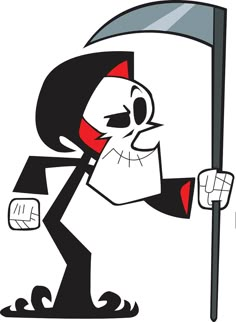

# questions

In [1156]:
question = "who is shah alam sir"

In [1157]:
required_document = vector_store_model.similarity_search(question, k = 5)
required_document

context = ""
for doc in required_document:
    context += doc.page_content

In [1158]:
prompt = f"""You are a document assistant. Your task is to extract information ONLY from the provided context.

Context:
{context}

Question: {question}

Response Guidelines:
1. Search the context for exact matches to the question
2. If the exact information exists, provide it
3. If the context mentions the topic but not the specific detail asked, say so
4. If the topic isn't in the context at all, state clearly: 
   "This information is not available in the provided documents."

Answer:"""


res = llm.invoke(prompt)
print(res.content)

Er. Mohd Shah Alam sir is a professor in the Computer Science and Engineering (CSE) department at CSJM University, Kanpur, and his assistant professor in the Department of Computer Science. He holds an M.Tech from Rama University, Kanpur and a B.Tech from UPTU, Lucknow.


# first question

In [1159]:
question = "who is director of uiet"


required_document = vector_store_model.similarity_search(question, k = 5)
required_document

context = ""
for doc in required_document:
    context += doc.page_content


prompt = f"""You are a document assistant. Your task is to extract information ONLY from the provided context.

Context:
{context}

Question: {question}

Response Guidelines:
1. Search the context for exact matches to the question
2. If the exact information exists, provide it
3. If the context mentions the topic but not the specific detail asked, say so
4. If the topic isn't in the context at all, state clearly: 
   "This information is not available in the provided documents."

Answer:"""

res = llm.invoke(prompt)
print(res.content)

Dr. Alok Kumar is the Director of University Institute of Engineering and Technology (UIET) at CSJMU.


# second question

In [1160]:
question = "i got 75% in 12th can you suggest me some courses"


required_document = vector_store_model.similarity_search(question, k = 5)
required_document

context = ""
for doc in required_document:
    context += doc.page_content


prompt = f"""You are a document assistant. Your task is to extract information ONLY from the provided context.

Context:
{context}

Question: {question}

Response Guidelines:
1. Search the context for exact matches to the question
2. If the exact information exists, provide it
3. If the context mentions the topic but not the specific detail asked, say so
4. If the topic isn't in the context at all, state clearly: 
   "This information is not available in the provided documents."

Answer:"""

res = llm.invoke(prompt)
print(res.content)

Based on your 75% score in 12th, you are eligible for several courses offered by CSJMU.

For B.Sc. (Combination) / B.Sc. Honours / B.Sc. Honours with Research, the eligibility criteria is Passed 12th class Examination with Physics, Chemistry, Mathematics or Physics, Chemistry, Biology. You meet this requirement.

The available duration of the course is 3 Years / 4 Years and there are 150 seats available.

As for the annual fee, it is Rs. 25,400 for B.Sc. (Combination) / B.Sc. Honours / B.Sc. Honours with Research.

You can also consider Certificate Course in Russian or Certificate Course (Painting), but they have different eligibility criteria and duration.

For M.Sc. (Master in Computer Science), you may need to meet additional requirements such as passing the first three semesters, but I couldn't find any information about the eligibility for M.Sc. 

I suggest checking with CSJMU directly or exploring more about these courses on their official website for a detailed understanding of 

In [1143]:
question = "i got 75% in 12th can you suggest me some courses"


required_document = vector_store_model.similarity_search(question, k = 40)
required_document

context = ""
for doc in required_document:
    context += doc.page_content


prompt = f"based on the context \n{context}\n tell me {question}"

res = llm.invoke(prompt)
print(res.content)

Congratulations on scoring 75% in your 12th class!

Considering your excellent academic record and interest in various fields, I've shortlisted a few courses that might suit you. Keep in mind that these suggestions are based on the information provided about CSJMU's programs.

**Science-related courses:**

1. **B.Sc. (Hons.) Physics**: With a strong foundation in physics, this course can help you develop a deeper understanding of the subject and prepare you for further studies or research.
2. **B.Sc. (Hons.) Chemistry**: This course is ideal if you're interested in chemistry and want to pursue a career in fields like pharmaceuticals, materials science, or environmental science.
3. **M.Sc. Physics**: Building on your 12th class physics knowledge, this master's program can help you specialize in areas like theoretical physics, condensed matter physics, or experimental physics.

**Computer Science and Engineering:**

1. **B.Tech. in Computer Science and Engineering (CSE)**: As a strong st

# third question

In [1180]:
question = "tell me syllabus of m.tech"


required_document = vector_store_model.similarity_search(question, k = 20)
required_document

context = ""
for doc in required_document:
    context += doc.page_content


prompt = f"""You are a document assistant. Your task is to extract information ONLY from the provided context.

Context:
{context}

Question: {question}

Response Guidelines:
1. Search the context for exact matches to the question
2. If the exact information exists, provide it
3. If the context mentions the topic but not the specific detail asked, say so
4. If the topic isn't in the context at all, state clearly: 
   "This information is not available in the provided documents."

Answer:"""


res = llm.invoke(prompt)
print(res.content)

Here are the syllabi for M.Tech:

1) Syllabus of M.Tech. in Computer Science and Engineering (AICTE Approved)
	* First semester subjects: ...
	* Second semester subjects: ...
	* Third semester subjects: ...
	* Fourth semester subjects: ...

2) Syllabus of M.Tech. in NanoScience and NanoTechnology
	* Eligibility criteria: B.Tech./B.E./ M.Sc. (Physics/Chemistry/Materials Science)
	* Duration: 2 Years
	* Seats available: 20 + EWS

3) Syllabus of M.Tech. in Electronics and Communication Engineering (AICTE Approved)
	* Eligibility criteria: B.Tech./B.E. in Electronics Engg, E&C Engg, E&E Engg, E&I Engg, E&Telecom Engg / M.Sc. in Electronics or Physics (specialization in Electronics)
	* Duration: 2 Years
	* Seats available: 30 + EWS


# fourth question

In [1175]:
question = "who is vice chansellor of csjmu"


required_document = vector_store_model.similarity_search(question, k = 5)
required_document

context = ""
for doc in required_document:
    context += doc.page_content


prompt = f"based on the context \n{context}\n tell me {question} if context is not according to the question then reply i don't no"

res = llm.invoke(prompt)
print(res.content)

According to the given context, Prof. Vinay Kumar Pathak is the Vice Chancellor of CSJM University (CSJMU).


In [1177]:
question = "who is vc of csjmu"


required_document = vector_store_model.similarity_search(question, k = 5)
required_document

context = ""
for doc in required_document:
    context += doc.page_content


prompt = f"based on the context \n{context}\n tell me {question} if context is not according to the question then reply i don't no"

res = llm.invoke(prompt)
print(res.content)

Unfortunately, there is no mention of the VC (Vice Chancellor) of CSJM University in the given text. The information provided is about various departments, faculties, and a section-8 company called CSJMIF, but it does not include details about the current Vice Chancellor of CSJM University.

However, I can suggest some possible ways to find the current VC of CSJM University:

1. Check the official website of CSJM University: You can visit the official website of CSJM University (csjmu.ac.in) and look for the "Administration" or "Governance" section, which might have information about the Vice Chancellor.
2. Contact the university administration: You can reach out to the university's administration department via phone or email to ask about the current VC.

As per my knowledge cutoff, I don't have any specific information about the current VC of CSJM University.
